In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('bangladesh_student_performance_updated.csv')

In [3]:
df.shape

(2018, 16)

In [4]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
2008,29/04/2018,M,19.0,Rural,GT3,Together,1,1,Services,Farmer,No,No,34671.0,1,3.63,2.89
1117,29/04/2018,F,18.0,Rural,GT3,Together,3,2,At_home,Teacher,No,No,41046.0,2,4.69,4.34
972,29/04/2018,F,17.0,Urban,LE3,Together,3,4,At_home,Services,No,No,87163.0,2,3.47,3.16
52,29/04/2018,F,17.0,Rural,LE3,Together,1,3,Teacher,Health,Yes,No,38041.0,3,2.56,2.11
1019,29/04/2018,M,18.0,Rural,LE3,Together,4,3,Other,Health,No,No,75863.0,1,4.25,3.73
250,29/04/2018,M,19.0,Rural,GT3,Together,2,3,Teacher,Services,No,No,57920.0,2,3.02,2.94
884,29/04/2018,F,18.0,Urban,GT3,Together,1,1,Other,Teacher,No,No,92214.0,5,4.20,3.27
1434,29/04/2018,M,17.0,Rural,GT3,Together,2,3,Teacher,Services,No,No,75167.0,2,3.87,3.36
365,29/04/2018,M,17.0,Rural,GT3,Together,0,2,Services,Business,Yes,No,27196.0,1,3.95,3.07
228,29/04/2018,F,17.0,Rural,GT3,Together,1,3,Teacher,Business,No,No,38774.0,1,4.10,3.59


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [6]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [7]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [8]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

# Doing EDA

Text(0.5, 0.98, 'Distribution of Numerical Features')

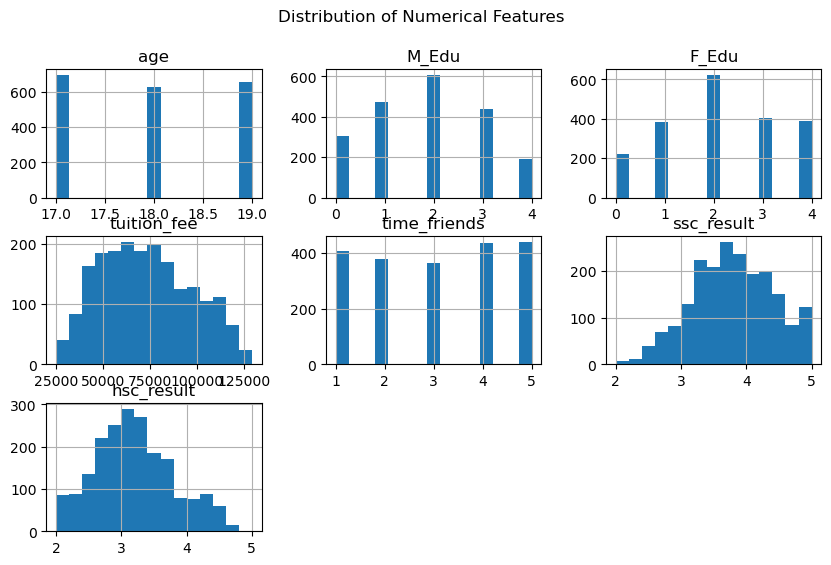

In [11]:
df.hist(bins=15, figsize=(10,6)) 

plt.suptitle("Distribution of Numerical Features")

In [12]:
numerical_columns = ['age','tuition_fee','ssc_result','hsc_result'] 

df[numerical_columns].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


# Corelation heatmap 

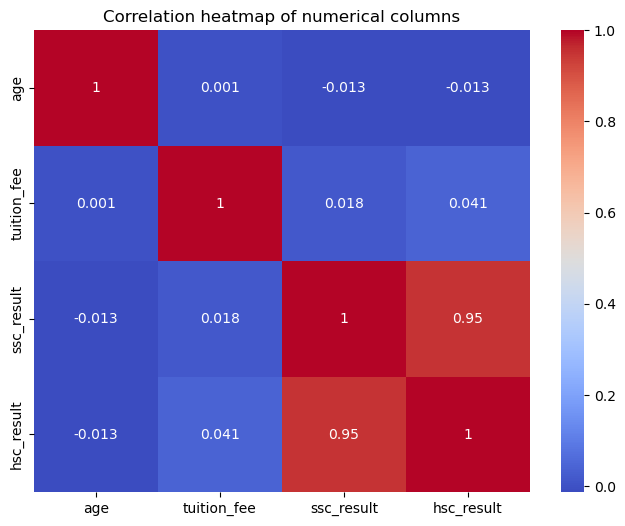

In [13]:
plt.figure(figsize=(8,6)) 

sns.heatmap(
    df[numerical_columns].corr(),annot=True,cmap='coolwarm'
)
plt.title("Correlation heatmap of numerical columns")
plt.show()

<Axes: xlabel='age'>

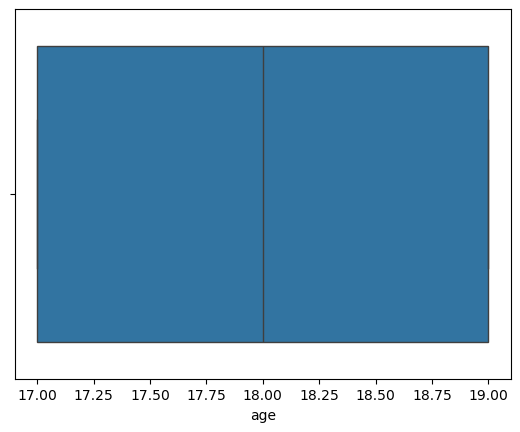

In [14]:
sns.boxplot(data=df,x='age')

<Axes: xlabel='tuition_fee'>

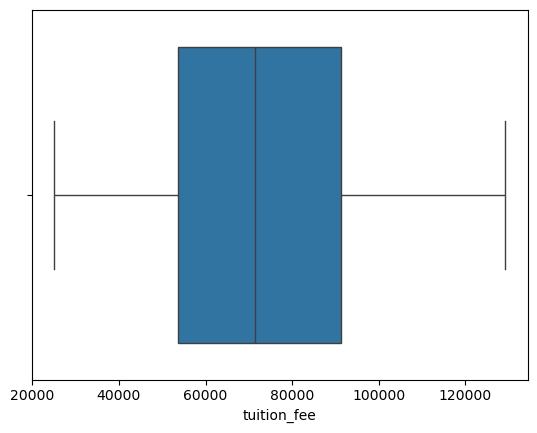

In [15]:
sns.boxplot(data=df,x='tuition_fee')

Pipeline in Scikit Learn

#Pre processing

In [18]:
from sklearn.model_selection import train_test_split 
from sklearn.impute  import SimpleImputer 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder , StandardScaler, MinMaxScaler 
from sklearn.pipeline import Pipeline

In [21]:
nominal_cat = ['gender','address','famsize','Pstatus','relationship','smoker','M_Job','F_Job']  #no order
ordinal_cat = ['M_Edu','F_Edu','time_friends'] # there is order 

M_edu_order = ['0','1','2','3','4'] 
F_edu_order = ['0','1','2','3','4'] 
time_friends_order = ['5','4','3','2','1'] 

numerical_col = ['age',	'tuition_fee','ssc_result'] 

In [22]:
numerical_transformer_pipe =  Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')), 
        ('scaler',StandardScaler())
    ]
)
numerical_transformer_pipe

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [24]:
nominal_transformer_pipe = Pipeline(
    steps=[('imputer',SimpleImputer(strategy='most_frequent')),
           ('encoder', OneHotEncoder(sparse_output=False,handle_unknown="ignore"))
          ]
)

nominal_transformer_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoding',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [26]:
ordinal_transformer_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OrdinalEncoder(categories=[M_edu_order,F_edu_order,time_friends_order ])),
        ('scaler',MinMaxScaler())
    ]
)